# 02 - Exploratory Analysis
### Chicago Housing Market | Listing Risk Prediction

This notebook keeps the EDA focused on one question:

**What does the Chicago housing market look like over time, and which signals could represent listing risk?**

**Pipeline sections:**
1. Load cleaned data from SQLite
2. Run basic SQL checks
3. Review dataset structure
4. Plot market trends over time
5. Explore listing-risk signals
6. Check correlations
7. Summarize findings for feature engineering






## 1. Load Data from SQLite

Notebook 01 cleaned the raw Redfin Metro Market Tracker file and saved the Chicago subset into a SQLite database. We will load that table in three small steps.






### 1.1 Import Libraries

First we import the Python libraries needed for SQL, data analysis, and charts.






In [1]:
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110






### 1.2 Load the SQL Table

Now we connect to `../sql/housing.db`, load the `chicago_housing` table, close the connection, and make sure the date column is treated as a real date.






In [2]:
conn = sqlite3.connect('../sql/housing.db')
df = pd.read_sql_query('SELECT * FROM chicago_housing', conn)
conn.close()

df['PERIOD_BEGIN'] = pd.to_datetime(df['PERIOD_BEGIN'])
df = df.sort_values('PERIOD_BEGIN').reset_index(drop=True)

print(f'Shape: {df.shape}')
df.head()






Shape: (168, 8)


,PERIOD_BEGIN,MEDIAN_SALE_PRICE,HOMES_SOLD,NEW_LISTINGS,INVENTORY,MONTHS_OF_SUPPLY,MEDIAN_DOM,PRICE_DROPS
0,2012-01-01,140000.0,3983.0,8123.0,39496.0,9.9,97.0,0.260128
1,2012-02-01,135000.0,4314.0,9637.0,39976.0,9.3,100.0,0.253127
2,2012-03-01,150000.0,5730.0,11617.0,40661.0,7.1,102.0,0.269005
3,2012-04-01,156500.0,6041.0,11111.0,40751.0,6.7,87.0,0.265834
4,2012-05-01,170000.0,7273.0,11190.0,40555.0,5.6,70.0,0.272765


### 1.3 Define Column Groups

These lists make the rest of the notebook easier to read. `NUMERIC` contains the market indicators we will analyze, and `RISK_SIGNALS` contains the columns that relate most directly to listing risk.






In [3]:
NUMERIC = [
    'MEDIAN_SALE_PRICE', 'HOMES_SOLD', 'NEW_LISTINGS',
    'INVENTORY', 'MONTHS_OF_SUPPLY', 'MEDIAN_DOM', 'PRICE_DROPS'
]

RISK_SIGNALS = ['PRICE_DROPS', 'MEDIAN_DOM', 'MONTHS_OF_SUPPLY']
MAIN_RISK_SIGNAL = 'PRICE_DROPS'

print('Numeric columns:')
print(NUMERIC)

print()
print('Risk signal columns:')
print(RISK_SIGNALS)






Numeric columns:
['MEDIAN_SALE_PRICE', 'HOMES_SOLD', 'NEW_LISTINGS', 'INVENTORY', 'MONTHS_OF_SUPPLY', 'MEDIAN_DOM', 'PRICE_DROPS']

Risk signal columns:
['PRICE_DROPS', 'MEDIAN_DOM', 'MONTHS_OF_SUPPLY']


## 2. Basic SQL Checks

Before plotting, we use SQL for quick validation. This gives SQL a real role in the workflow: checking row counts, date coverage, and high-level yearly market patterns directly from the database.






In [4]:
conn = sqlite3.connect('../sql/housing.db')

row_count = pd.read_sql_query(
    'SELECT COUNT(*) AS total_rows FROM chicago_housing',
    conn
)

date_range = pd.read_sql_query(
    '''
    SELECT
        MIN(PERIOD_BEGIN) AS first_month,
        MAX(PERIOD_BEGIN) AS last_month,
        COUNT(DISTINCT PERIOD_BEGIN) AS unique_months
    FROM chicago_housing
    ''',
    conn
)

records_per_month = pd.read_sql_query(
    '''
    SELECT
        PERIOD_BEGIN,
        COUNT(*) AS records
    FROM chicago_housing
    GROUP BY PERIOD_BEGIN
    ORDER BY PERIOD_BEGIN
    LIMIT 10
    ''',
    conn
)

yearly_summary = pd.read_sql_query(
    '''
    SELECT
        strftime('%Y', PERIOD_BEGIN) AS year,
        ROUND(AVG(MEDIAN_SALE_PRICE), 0) AS avg_sale_price,
        ROUND(AVG(INVENTORY), 0) AS avg_inventory,
        ROUND(AVG(MONTHS_OF_SUPPLY), 2) AS avg_months_supply,
        ROUND(AVG(MEDIAN_DOM), 1) AS avg_days_on_market,
        ROUND(AVG(PRICE_DROPS), 3) AS avg_price_drops
    FROM chicago_housing
    GROUP BY year
    ORDER BY year
    ''',
    conn
)

conn.close()

print('Row count:')
display(row_count)

print('Date range:')
display(date_range)

print('Records per month sample:')
display(records_per_month)

print('Yearly market summary:')
display(yearly_summary)






Row count:


,total_rows
0,168


Date range:


,first_month,last_month,unique_months
0,2012-01-01 00:00:00,2025-12-01 00:00:00,168


Records per month sample:


,PERIOD_BEGIN,records
0,2012-01-01 00:00:00,1
1,2012-02-01 00:00:00,1
2,2012-03-01 00:00:00,1
3,2012-04-01 00:00:00,1
4,2012-05-01 00:00:00,1
5,2012-06-01 00:00:00,1
6,2012-07-01 00:00:00,1
7,2012-08-01 00:00:00,1
8,2012-09-01 00:00:00,1
9,2012-10-01 00:00:00,1


Yearly market summary:


,year,avg_sale_price,avg_inventory,avg_months_supply,avg_days_on_market,avg_price_drops
0,2012,157867.0,37944.0,6.17,76.0,0.254
1,2013,175292.0,30414.0,4.02,51.3,0.223
2,2014,191958.0,32263.0,4.43,49.1,0.257
3,2015,206208.0,33654.0,4.39,54.9,0.250
4,2016,220579.0,30744.0,3.85,49.0,0.243
5,2017,233579.0,32323.0,3.97,61.7,0.210
6,2018,242238.0,31004.0,3.97,60.5,0.220
7,2019,246729.0,33878.0,4.50,71.4,0.215
8,2020,267042.0,23263.0,3.08,45.0,0.227
9,2021,298050.0,18090.0,1.93,20.1,0.216


## 3. Dataset Overview

Now that SQL confirms the table loaded correctly, we inspect the pandas DataFrame: column types, missing values, and summary statistics.






In [5]:
print('Dataset shape:')
print(df.shape)

print('Date range:')
print(df['PERIOD_BEGIN'].min(), 'to', df['PERIOD_BEGIN'].max())

print('Data types:')
print(df.dtypes)

print('Missing Values:')
print(df.isnull().sum())

print('Summary Statistics:')
print(df[NUMERIC].describe().round(2))

Dataset shape:
(168, 8)
Date range:
2012-01-01 00:00:00 to 2025-12-01 00:00:00
Data types:
PERIOD_BEGIN         datetime64[ns]
MEDIAN_SALE_PRICE           float64
HOMES_SOLD                  float64
NEW_LISTINGS                float64
INVENTORY                   float64
MONTHS_OF_SUPPLY            float64
MEDIAN_DOM                  float64
PRICE_DROPS                 float64
dtype: object
Missing Values:
PERIOD_BEGIN         0
MEDIAN_SALE_PRICE    0
HOMES_SOLD           0
NEW_LISTINGS         0
INVENTORY            0
MONTHS_OF_SUPPLY     0
MEDIAN_DOM           0
PRICE_DROPS          0
dtype: int64
Summary Statistics:
       MEDIAN_SALE_PRICE  HOMES_SOLD  NEW_LISTINGS  INVENTORY  \
count             168.00      168.00        168.00     168.00   
mean           255322.08     7667.20       9732.80   27349.98   
std             63638.63     1963.33       2927.95    7435.98   
min            135000.00     3861.00       3452.00   13432.00   
25%            209750.00     6175.25       7696.7

## 4. Market Trends Over Time

Because this is a housing-market project, the most useful EDA is time-series EDA. We aggregate each month using the median, then plot the main market indicators over time.






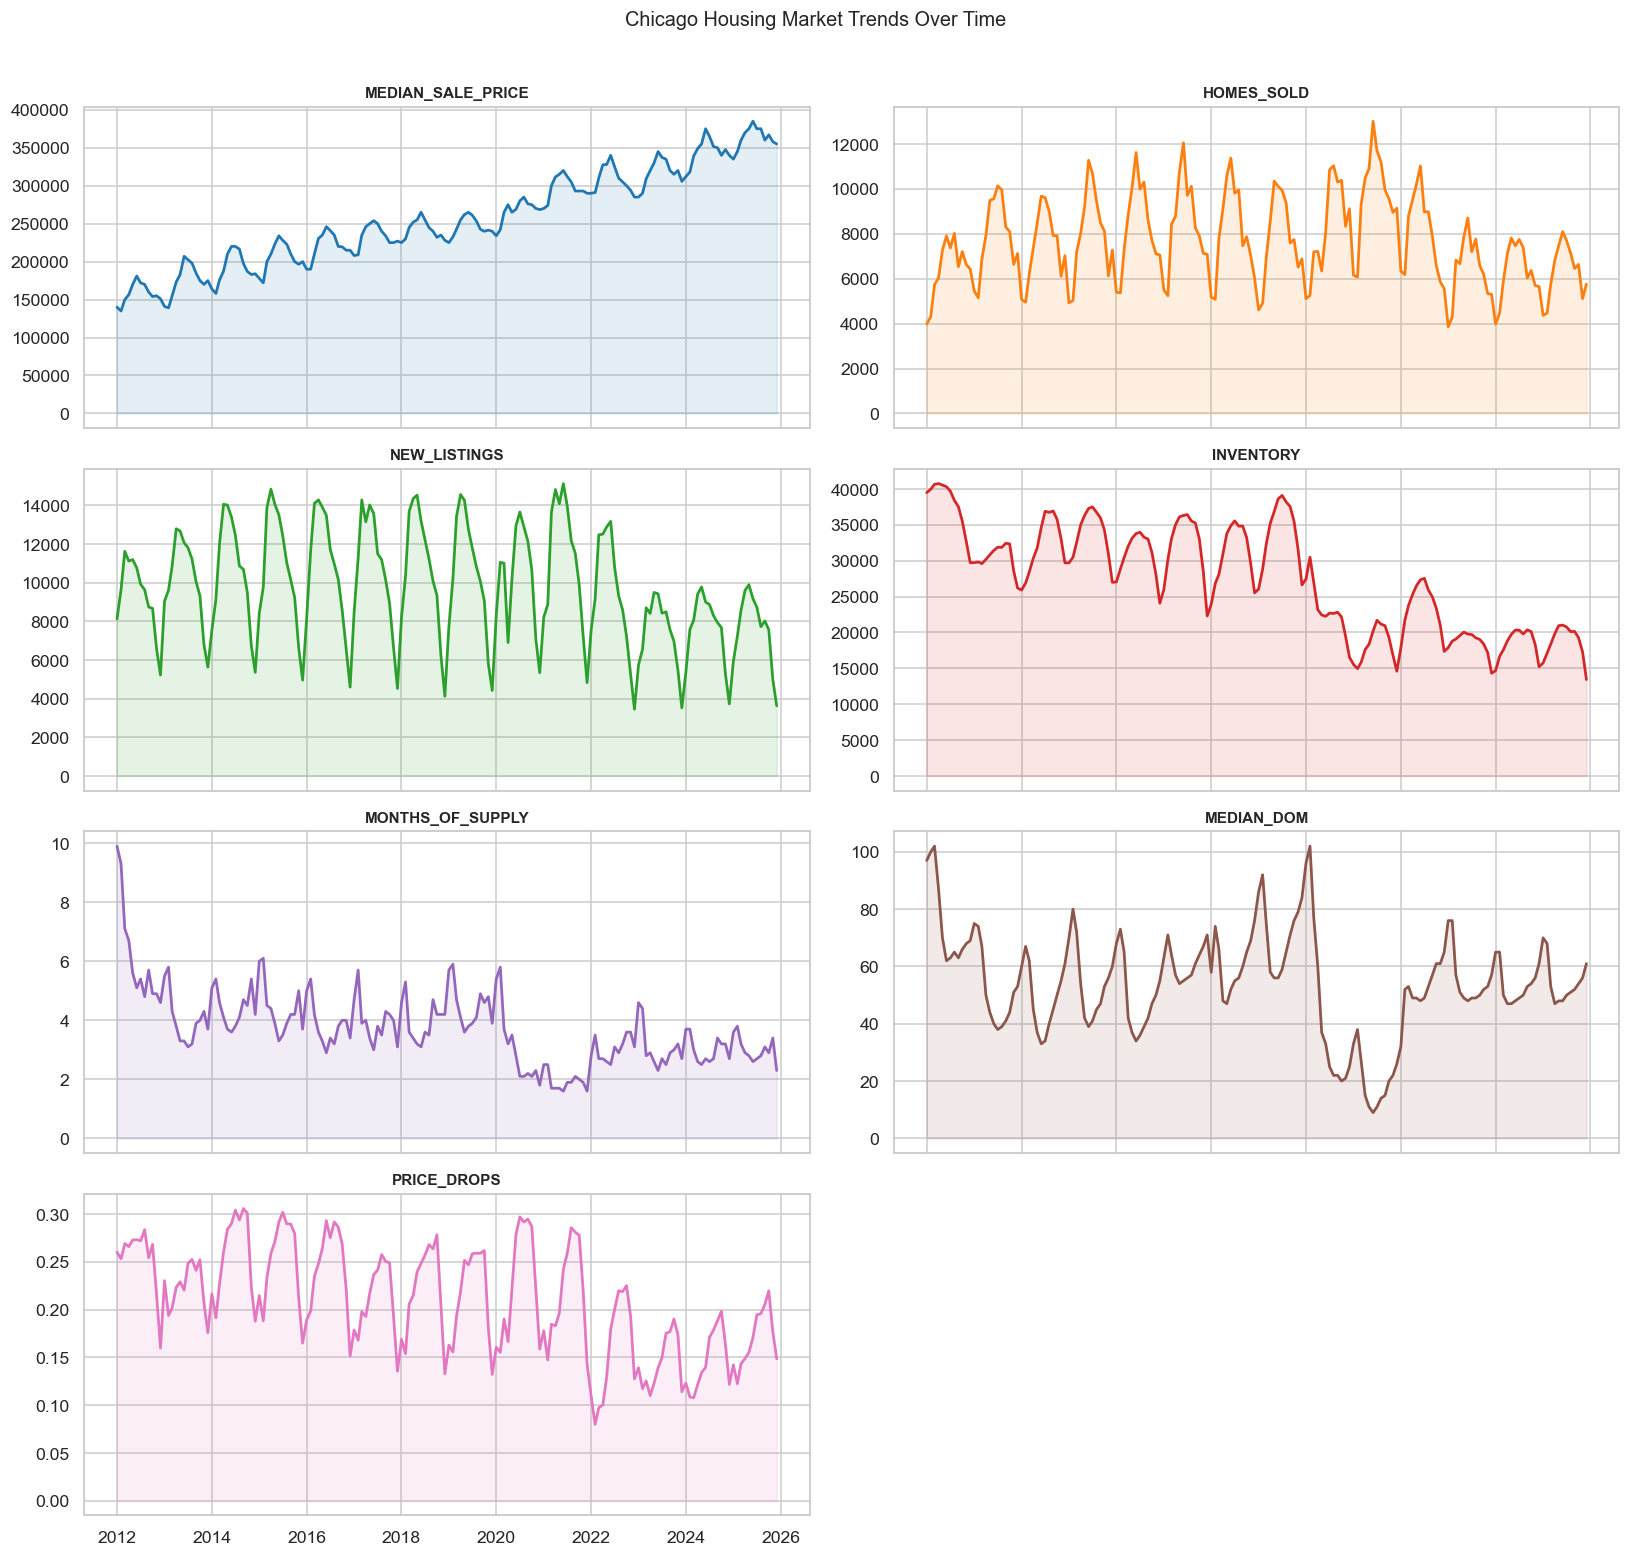

In [6]:
monthly = df.groupby('PERIOD_BEGIN', as_index=False)[NUMERIC].median()

trend_cols = [
    'MEDIAN_SALE_PRICE', 'HOMES_SOLD', 'NEW_LISTINGS',
    'INVENTORY', 'MONTHS_OF_SUPPLY', 'MEDIAN_DOM', 'PRICE_DROPS'
]

fig, axes = plt.subplots(4, 2, figsize=(15, 14), sharex=True)
axes = axes.flatten()
colors = sns.color_palette('tab10', len(trend_cols))

for ax, col, color in zip(axes, trend_cols, colors):
    ax.plot(monthly['PERIOD_BEGIN'], monthly[col], color=color, linewidth=1.8)
    ax.fill_between(monthly['PERIOD_BEGIN'], monthly[col], color=color, alpha=0.12)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

axes[-1].set_visible(False)
fig.suptitle('Chicago Housing Market Trends Over Time', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()






## 5. Listing-Risk Signals

For this project, listing risk means a market where sellers may have a harder time selling quickly or at the original asking price.

The main risk signals are:

- `PRICE_DROPS`: more sellers are lowering prices
- `MEDIAN_DOM`: homes are taking longer to sell
- `MONTHS_OF_SUPPLY`: inventory is high relative to demand

Notebook 03 will combine these into a formal `RISK_SCORE` and `RISK_LABEL`. Here we first check whether these signals move in meaningful ways over time.






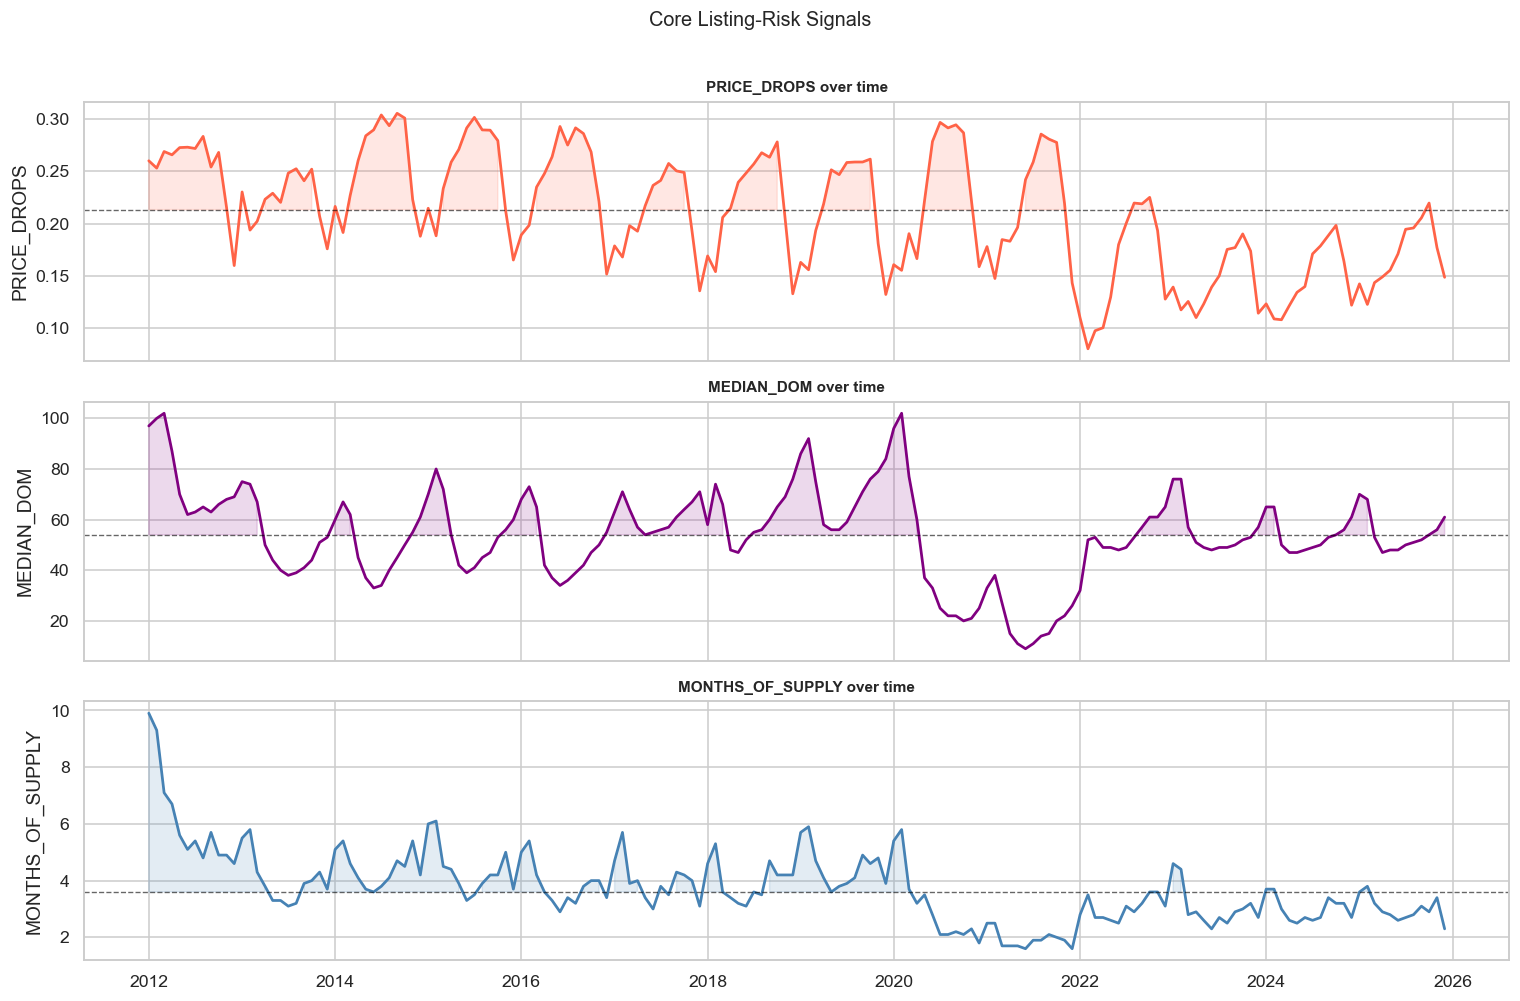

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
risk_colors = ['tomato', 'purple', 'steelblue']

for ax, col, color in zip(axes, RISK_SIGNALS, risk_colors):
    ax.plot(monthly['PERIOD_BEGIN'], monthly[col], color=color, linewidth=1.8)
    ax.axhline(monthly[col].median(), color='black', linestyle='--', linewidth=0.9, alpha=0.6)
    ax.fill_between(
        monthly['PERIOD_BEGIN'],
        monthly[col],
        monthly[col].median(),
        where=monthly[col] >= monthly[col].median(),
        color=color,
        alpha=0.15
    )
    ax.set_title(f'{col} over time', fontsize=10, fontweight='bold')
    ax.set_ylabel(col)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
fig.suptitle('Core Listing-Risk Signals', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()






In [8]:
risk_summary = monthly[RISK_SIGNALS].describe().round(3)
print('Risk signal summary statistics')
display(risk_summary)

highest_price_drop_months = (
    monthly[['PERIOD_BEGIN'] + RISK_SIGNALS]
    .sort_values(MAIN_RISK_SIGNAL, ascending=False)
    .head(10)
    .copy()
)
highest_price_drop_months['PERIOD_BEGIN'] = highest_price_drop_months['PERIOD_BEGIN'].dt.strftime('%Y-%m')

print('Top 10 months by price-drop rate')
display(highest_price_drop_months.round(3))






Risk signal summary statistics


,PRICE_DROPS,MEDIAN_DOM,MONTHS_OF_SUPPLY
count,168.000,168.000,168.000
mean,0.209,53.970,3.742
std,0.056,17.958,1.275
min,0.080,9.000,1.600
25%,0.166,45.000,2.900
50%,0.213,54.000,3.600
75%,0.259,65.000,4.325
max,0.306,102.000,9.900


Top 10 months by price-drop rate


,PERIOD_BEGIN,PRICE_DROPS,MEDIAN_DOM,MONTHS_OF_SUPPLY
32,2014-09,0.306,45.0,4.7
30,2014-07,0.304,34.0,3.8
42,2015-07,0.302,41.0,3.5
33,2014-10,0.301,50.0,4.5
102,2020-07,0.297,25.0,2.1
104,2020-09,0.295,22.0,2.2
31,2014-08,0.294,40.0,4.1
53,2016-06,0.293,34.0,2.9
55,2016-08,0.292,39.0,3.2
103,2020-08,0.292,22.0,2.1


## 6. Correlation Analysis

Correlation helps us see which market indicators move together. This does not prove causation, but it helps us decide which features may be useful in the next notebook.






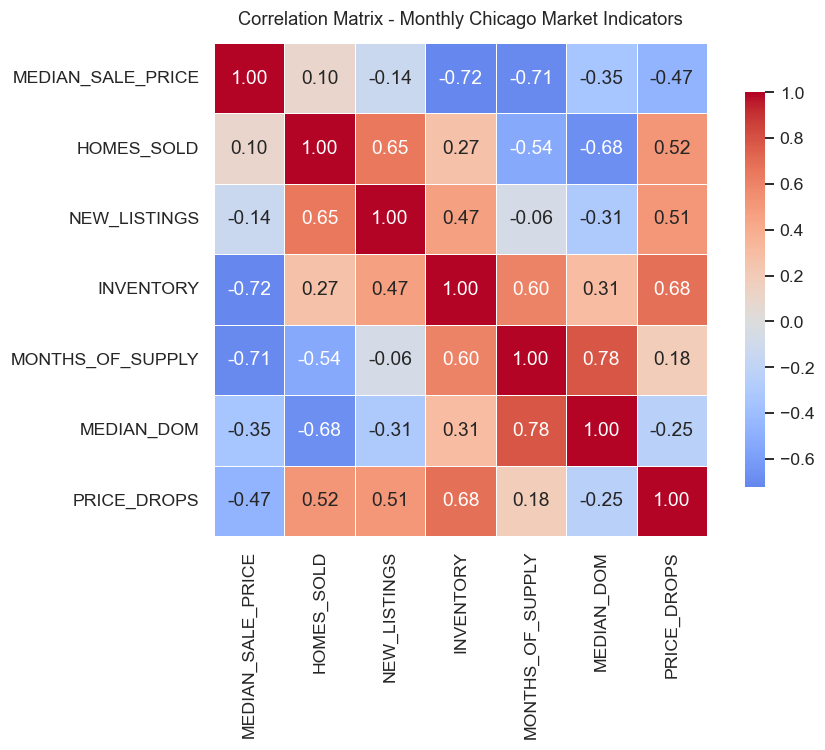

In [9]:
corr = monthly[NUMERIC].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix - Monthly Chicago Market Indicators', fontsize=12, pad=12)
plt.tight_layout()
plt.show()






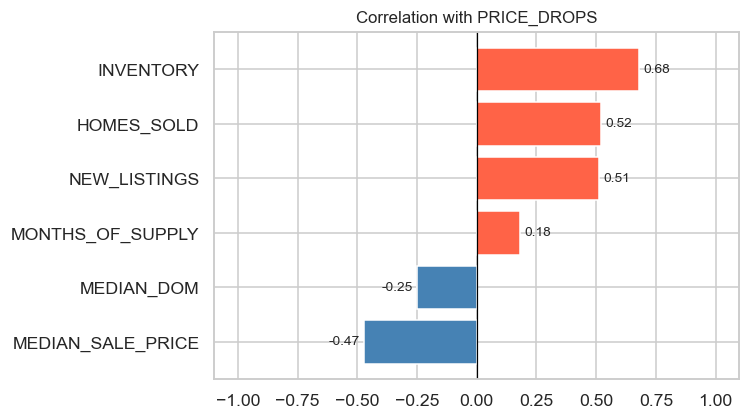

Ranked correlation with PRICE_DROPS


,correlation
MEDIAN_SALE_PRICE,-0.472
MEDIAN_DOM,-0.250
MONTHS_OF_SUPPLY,0.182
NEW_LISTINGS,0.513
HOMES_SOLD,0.519
INVENTORY,0.681


In [10]:
target_corr = corr[MAIN_RISK_SIGNAL].drop(MAIN_RISK_SIGNAL).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue' if value < 0 else 'tomato' for value in target_corr]
bars = ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_xlim(-1.1, 1.1)
ax.set_title(f'Correlation with {MAIN_RISK_SIGNAL}', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Ranked correlation with {MAIN_RISK_SIGNAL}')
display(target_corr.to_frame('correlation').round(3))






## 7. Key Findings

After running this notebook, use the charts and tables above to support these project decisions:

- The cleaned Chicago housing data is stored in SQLite and can be validated with SQL.
- The dataset covers monthly Chicago housing-market conditions over time.
- `PRICE_DROPS`, `MEDIAN_DOM`, and `MONTHS_OF_SUPPLY` are reasonable listing-risk signals because they describe seller pressure, slower sales, and excess supply.
- Notebook 03 should turn these signals into model-ready features, including lag features, rolling averages, and risk targets.

**Next step:** open `03_feature_engineering.ipynb` and build the engineered dataset for modeling.




